In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import sklearn
df = sns.load_dataset("iris")
df_num = df.select_dtypes(include=[np.number])
print ("* 5 dòng đầu của dataset:")
print (df.head())
print ("* Số dòng của dataset:", df.shape[0])
print ("* Số cột của dataset:", df.shape[1])
print ("* Kiểu dữ liệu của các cột:\n", df.dtypes)

stats = df_num.describe().T
stats["mode"] = df_num.mode().iloc[0]
stats["var"] = df_num.var()
stats["iqr"] = stats["75%"] - stats["25%"]
stats = stats.rename(columns={
    "50%" : "median",
    "25%" : "q1",
    "75%" : "q3"
})
stats_order = ["mean", "median", "mode", "var", "std", "min", "max", "q1", "q3", "iqr"]
stats = stats[stats_order]
print("* Mean, median, mode, var, std, min, max, Q1, Q3, IQR của các biến số:")
print(stats)

df_setosa = df[df['species'] == 'setosa']
setosa_mean = df_setosa.mean(numeric_only=True)
setosa_std = df_setosa.std(numeric_only=True)
df_versicolor = df[df['species'] == 'versicolor']
versicolor_mean = df_versicolor.mean(numeric_only=True)
versicolor_std = df_versicolor.std(numeric_only=True)
df_virginica = df[df['species'] == 'virginica']
virginica_mean = df_virginica.mean(numeric_only=True)
virginica_std = df_virginica.std(numeric_only=True)
species_order = pd.DataFrame({
    "setosa_mean": setosa_mean,
    "setosa_std": setosa_std,
    "versicolor_mean": versicolor_mean,
    "versicolor_std": versicolor_std,
    "virginica_mean": virginica_mean,
    "virginica_std": virginica_std
})
species_order_T = species_order.T
print("* Mean, std từng nhóm:")
print(species_order_T)

* 5 dòng đầu của dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
* Số dòng của dataset: 150
* Số cột của dataset: 5
* Kiểu dữ liệu của các cột:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
* Mean, median, mode, var, std, min, max, Q1, Q3, IQR của các biến số:
                  mean  median  mode       var       std  min  max   q1   q3  \
sepal_length  5.843333    5.80   5.0  0.685694  0.828066  4.3  7.9  5.1  6.4   
sepal_width   3.057333    3.00   3.0  0.189979  0.435866  2.0  4.4  2.8  3.3   
petal_length  3.758000    4.35   1.4  3.116278  1.765298  1.0  6.

Phần 1

Nhận xét: nhóm khác biệt rõ nhất so với các nhóm còn lại là setosa, với petal_length và petal_width có sự khác biệt rõ ràng so với 2 species còn lại

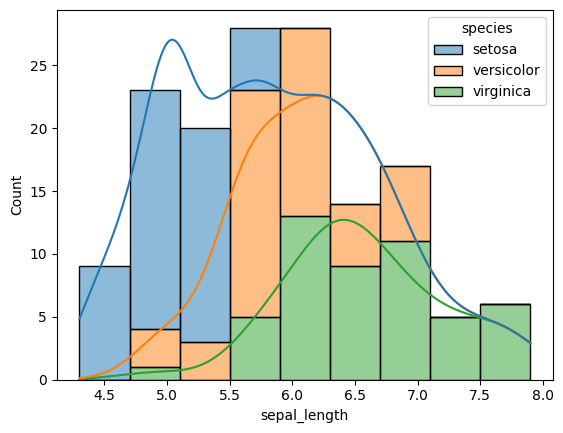

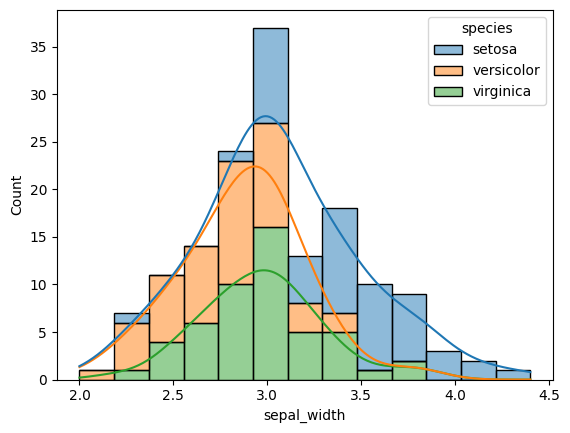

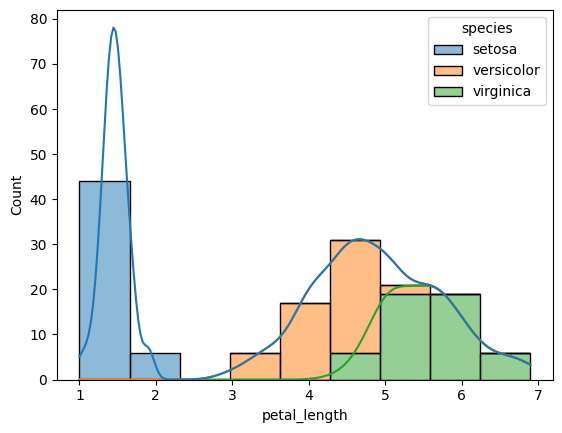

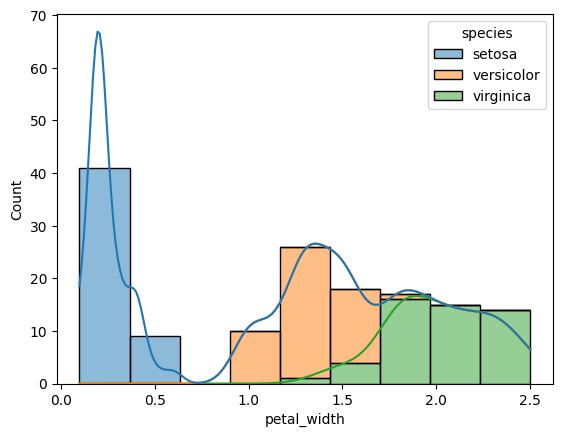

In [2]:
sns.histplot(data=df, x="sepal_length", hue="species", kde=True, multiple="stack")
plt.pyplot.show()
sns.histplot(data=df, x="sepal_width", hue="species", kde=True, multiple="stack")
plt.pyplot.show()
sns.histplot(data=df, x="petal_length", hue="species", kde=True, multiple="stack")
plt.pyplot.show()
sns.histplot(data=df, x="petal_width", hue="species", kde=True, multiple="stack")
plt.pyplot.show()

Phần 2.1: Nhận xét hình dạng phân phối của các biến số

Dựa trên biểu đồ Histogram kết hợp đường đường cong ước lượng mật độ hạt nhân (KDE) được vẽ theo phương pháp xếp chồng (stack), hình dạng phân phối của các đặc trưng được phân tích cụ thể như sau:

1. Chiều dài đài hoa (`sepal_length`):
   Hình dạng: Phân phối tổng thể tương đối đối xứng, có dạng đơn đỉnh và khá gần với phân phối chuẩn. 
   Đặc điểm: Tuy nhiên, phần đỉnh hơi phẳng và rộng do có sự gối đầu rõ rệt giữa 3 loài (Setosa tập trung ở phía bên trái - kích thước nhỏ, Versicolor ở giữa và Virginica ở phía bên phải - kích thước lớn).

2. Chiều rộng đài hoa (`sepal_width`):
   Hình dạng: Đây là biến có phân phối gần với phân phối chuẩn nhất trong cả 4 đặc trưng.
   Đặc điểm: Biểu đồ có hình chuông đối xứng rất rõ ràng, tập trung mạnh vào một đỉnh duy nhất ở khoảng giá trị 3.0. Giữa các loài có sự chồng lấn (overlap) rất lớn, cho thấy đặc trưng này ít có sự khác biệt rõ rệt giữa các loài.

3. Chiều dài cánh hoa (`petal_length`):
   Hình dạng: Phân phối tổng thể rõ ràng là phân phối nhiều đỉnh (đa đỉnh / bimodal).
   Đặc điểm: Biểu đồ bị tách tách biệt hoàn toàn thành hai cụm rõ rệt và có một khoảng trống lớn (gap) ở giữa (khoảng từ 2.0 đến 3.0 cm). Cụm bên trái hoàn toàn là loài *Setosa* với kích thước cánh hoa rất ngắn, cụm bên phải là sự kết hợp của *Versicolor* và *Virginica*.

4. Chiều rộng cánh hoa (`petal_width`):
   Hình dạng: Tương tự như `petal_length`, biến này cũng có phân phối nhiều đỉnh (đa đỉnh) và không hề tuân theo phân phối chuẩn.
   Đặc điểm: Có sự phân cụm cực kỳ rõ ràng. Loài *Setosa* nằm biệt lập hoàn toàn tạo thành một đỉnh nhọn ở vùng giá trị thấp (dưới 0.6 cm). Trong khi đó, *Versicolor* và *Virginica* tạo thành một cụm đa đỉnh thứ hai ở vùng giá trị cao hơn (từ 1.0 đến 2.5 cm).

Kết luận ngắn gọn: Các đặc trưng về đài hoa (`sepal`) có xu hướng tiệm cận phân phối chuẩn, trong khi các đặc trưng về cánh hoa (`petal`) có phân phối đa đỉnh do tính chất phân cụm và tách biệt rất mạnh của loài *Setosa* so với hai loài còn lại.

C:\Users\Windows\AppData\Local\Temp\ipykernel_22568\2756373617.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.pyplot.boxplot(df_setosa_num, labels=df_setosa_num.columns)
C:\Users\Windows\AppData\Local\Temp\ipykernel_22568\2756373617.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.pyplot.boxplot(df_versicolor_num, labels=df_versicolor_num.columns)
C:\Users\Windows\AppData\Local\Temp\ipykernel_22568\2756373617.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.pyplot.boxplot(df_virginica_num, labels=df_virginica_num.columns)


Text(0.5, 1.0, 'Boxplot - Virginica')

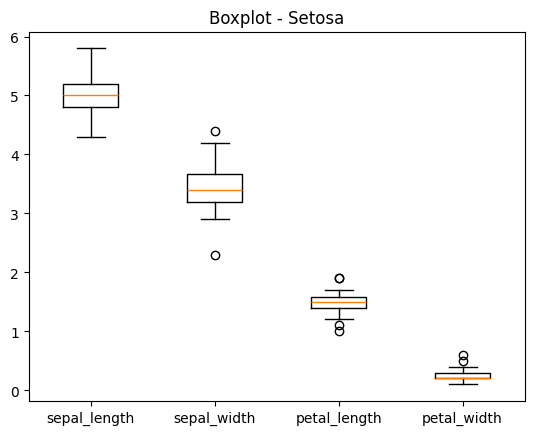

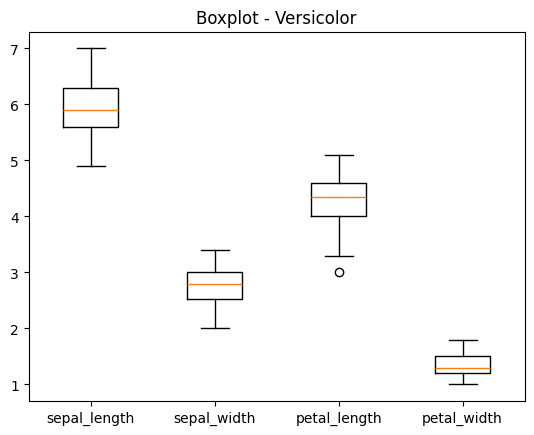

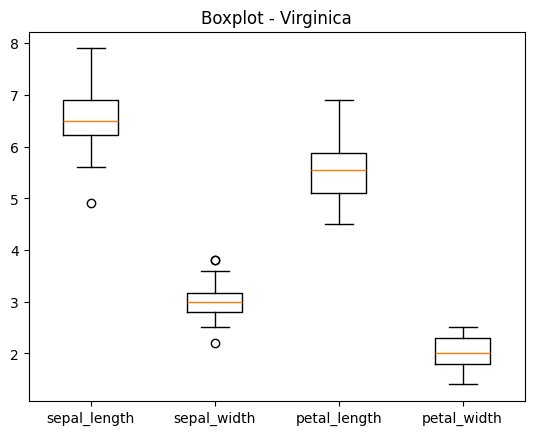

In [3]:
df_setosa_num = df_setosa.drop(columns=['species'])
plt.pyplot.figure()
plt.pyplot.boxplot(df_setosa_num, labels=df_setosa_num.columns)
plt.pyplot.title('Boxplot - Setosa')
df_versicolor_num = df_versicolor.drop(columns=['species'])
plt.pyplot.figure()
plt.pyplot.boxplot(df_versicolor_num, labels=df_versicolor_num.columns)
plt.pyplot.title('Boxplot - Versicolor')
df_virginica_num = df_virginica.drop(columns=['species'])
plt.pyplot.figure()
plt.pyplot.boxplot(df_virginica_num, labels=df_virginica_num.columns)
plt.pyplot.title('Boxplot - Virginica')

Phần 2.2: Nhận xét biểu đồ Boxplot

Dựa vào các biểu đồ Boxplot, ta có thể so sánh sự phân bố của 4 đặc trưng giữa 3 loài hoa như sau:

Sự phân tách rõ rệt ở kích thước cánh hoa (Petal): Các biến `petal_length` và `petal_width` cho thấy sự khác biệt cực kỳ lớn giữa các loài. Loài *Setosa* có cánh hoa rất nhỏ và độ phân tán dữ liệu rất hẹp (hộp boxplot ngắn). *Versicolor* nằm ở mức trung bình, trong khi *Virginica* có cánh hoa dài và rộng nhất.
Kích thước đài hoa (Sepal): `sepal_length` có xu hướng tăng dần theo thứ tự: Setosa < Versicolor < Virginica. 
    Ngược lại, `sepal_width` (chiều rộng đài hoa) của loài *Setosa* lại có giá trị trung vị cao nhất so với hai loài còn lại.

Giá trị ngoại lệ (Outliers): Biểu đồ Boxplot giúp phát hiện một số điểm dữ liệu bất thường (các chấm nằm ngoài hai đầu "râu" của hộp). Điển hình nhất là ở biến `sepal_width`, ta thấy có một vài mẫu hoa có kích thước đài hoa rộng hoặc hẹp bất thường so với phần đông đồng loại.

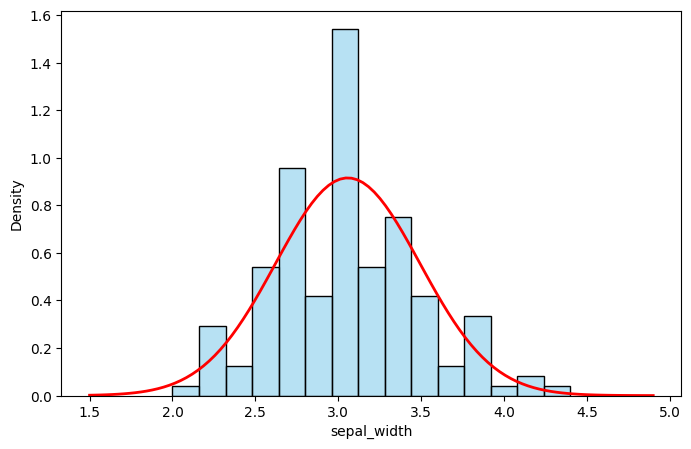

In [4]:
plt.pyplot.figure(figsize=(8, 5))
sns.histplot(df['sepal_width'], bins=15, stat='density', color='skyblue', label='Dữ liệu thực tế (Histogram)', alpha=0.6)
x = np.linspace(df['sepal_width'].min() - 0.5, df['sepal_width'].max() + 0.5, 100)
pdf = (1 / (df['sepal_width'].std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - df['sepal_width'].mean()) / df['sepal_width'].std())**2)
plt.pyplot.plot(x, pdf, color='red', lw=2, label='PDF Lý thuyết (Normal)')

Phần 2.3: Nhận xét mức độ khớp

Dựa vào biểu đồ vẽ chồng giữa Histogram của dữ liệu thực tế (màu xanh) và đường cong mật độ xác suất (PDF) lý thuyết (màu đỏ) đối với biến `sepal_width`, ta có thể rút ra các nhận xét sau:

Mức độ khớp rất tốt: Các cột Histogram của dữ liệu thực tế phân bổ gần như hoàn hảo và bám rất sát theo đường cong hình chuông của phân phối chuẩn lý thuyết.
Sự hội tụ tại đỉnh và đuôi: Đỉnh của phân phối thực tế nằm ngay vị trí trung tâm (quanh giá trị 3.0), hoàn toàn trùng khớp với đỉnh của đường PDF. Hai phần đuôi (trái và phải) của dữ liệu thực tế cũng giảm dần một cách đối xứng, bám sát độ dốc của đường chuẩn.
Kết luận: Đặc trưng `sepal_width` (chiều rộng đài hoa) của tập dữ liệu Iris hoàn toàn tuân theo phân phối chuẩn (Normal Distribution).

Ma trận hiệp phương sai:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Ma trận tương quan:
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


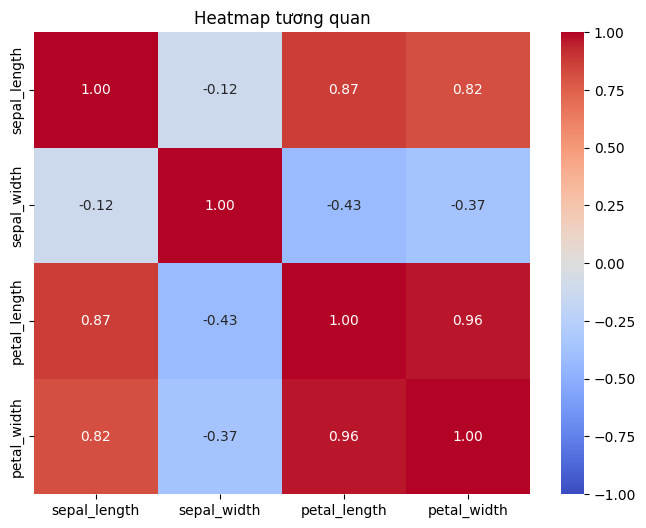

In [5]:
df_cov = df_num.cov()
df_corr = df_num.corr()
print("Ma trận hiệp phương sai:\n", df_cov)
print("Ma trận tương quan:\n", df_corr)
plt.pyplot.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.pyplot.title("Heatmap tương quan")
plt.pyplot.show()

Phần 3.1 và 3.2: Nhận xét Phân tích đa biến & Tương quan

Dựa vào ma trận tương quan và biểu đồ Heatmap, ta có thể đánh giá mối quan hệ tuyến tính giữa các cặp biến số như sau:

Cặp biến có tương quan mạnh nhất: Nhìn vào các ô màu đỏ đậm nhất trên Heatmap (bỏ qua đường chéo chính có giá trị 1.00), ta thấy cặp biến `petal_length` (chiều dài cánh hoa) và `petal_width` (chiều rộng cánh hoa) có hệ số tương quan dương cao nhất, lên tới **0.96**. Điều này chỉ ra một mối quan hệ đồng biến cực kỳ chặt chẽ: cánh hoa càng dài thì bề ngang cũng càng rộng.
Các mối tương quan đáng chú ý khác: Biến `sepal_length` cũng có độ tương quan dương khá mạnh với kích thước cánh hoa: tương quan với `petal_length` là 0.87 và với `petal_width` là 0.82. Ngược lại, biến `sepal_width` lại có tương quan âm nhẹ đến trung bình với các biến còn lại (đặc biệt là với `petal_length` ở mức -0.43).
Dấu hiệu đa cộng tuyến: Đa cộng tuyến xảy ra khi các biến độc lập (features) có sự tương quan tuyến tính rất mạnh với nhau. Với hệ số tương quan đạt mức 0.96 (tiệm cận 1.0) giữa `petal_length` và `petal_width`, đây là dấu hiệu đa cộng tuyến rất rõ ràng. Ngoài ra, sự liên kết mạnh của `sepal_length` với hai biến này cũng góp phần làm tăng rủi ro đa cộng tuyến. Nếu sử dụng tập dữ liệu này cho các mô hình hồi quy tuyến tính (Linear Regression), ta có thể cân nhắc loại bỏ bớt một số biến có tương quan quá cao để giúp mô hình ổn định hơn.

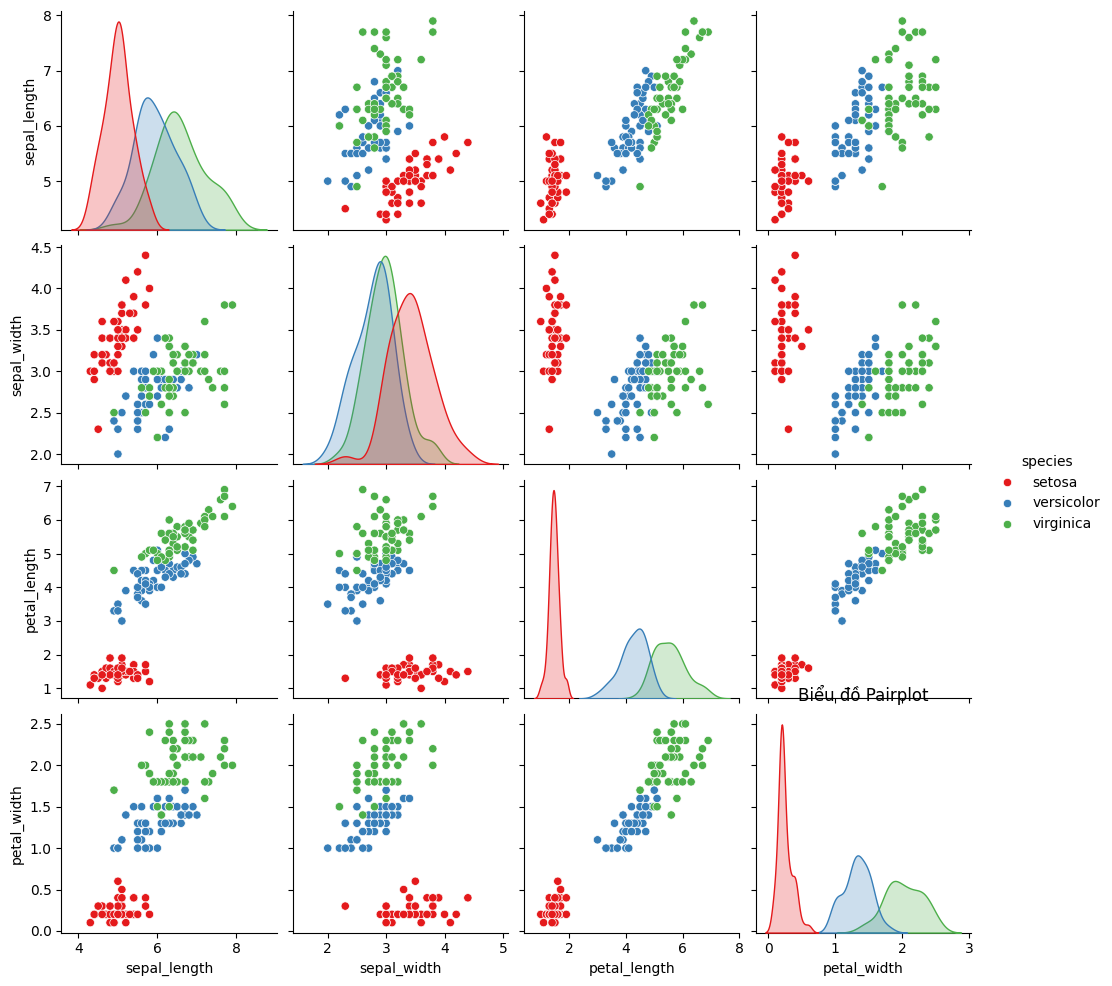

In [6]:
sns.pairplot(df, hue="species", palette="Set1")
plt.pyplot.title("Biểu đồ Pairplot", y=1.02)
plt.pyplot.show()

Phần 3.3 Nhận xét quan hệ giữa các biến qua biểu đồ Pairplot

Dựa vào biểu đồ phân tán theo cặp (Pairplot) được phân loại bằng màu sắc theo từng loài hoa, ta có thể rút ra những nhận xét trực quan sau:

Sự phân tách cụm (Clustering) rõ rệt của loài Setosa: Trong hầu hết mọi biểu đồ phân tán 2 chiều (đặc biệt là các đồ thị có chứa biến `petal_length` hoặc `petal_width`), loài *Setosa* (cụm màu đỏ) luôn hội tụ thành một nhóm tách biệt hoàn toàn, nằm cách xa so với hai loài còn lại. 
Sự chồng lấn giữa Versicolor và Virginica: Hai loài *Versicolor* (màu xanh dương) và *Virginica* (màu xanh lá) có xu hướng phân bố sát nhau tạo thành một dải liên tục và có sự chồng lấn nhẹ ở phần ranh giới. Điều này cho thấy kích thước của hai loài này có sự tương đồng nhất định.
Minh họa rõ ràng mối quan hệ tuyến tính: Khi nhìn vào ô đồ thị giao giữa `petal_length` và `petal_width`, các điểm dữ liệu trải dài tạo thành một dải tuyến tính đi lên rất rõ nét. Điều này minh họa trực quan và khẳng định lại kết quả hệ số tương quan rất cao (0.96 - có dấu hiệu đa cộng tuyến) đã quan sát được ở ma trận Heatmap.
Đánh giá giá trị phân loại của các đặc trưng: Các đồ thị dọc theo đường chéo chính (biểu đồ phân phối KDE) và các đồ thị phân tán cho thấy các đặc trưng về cánh hoa (`petal`) làm rất tốt nhiệm vụ phân loại 3 giống hoa. Ngược lại, ở ô đồ thị giao giữa `sepal_length` và `sepal_width`, dữ liệu phân tán khá lộn xộn, chứng tỏ đài hoa không mang nhiều ý nghĩa quyết định khi dùng để phân biệt các loài.

Xác suất hậu nghiệm P(B|+): 0.1667


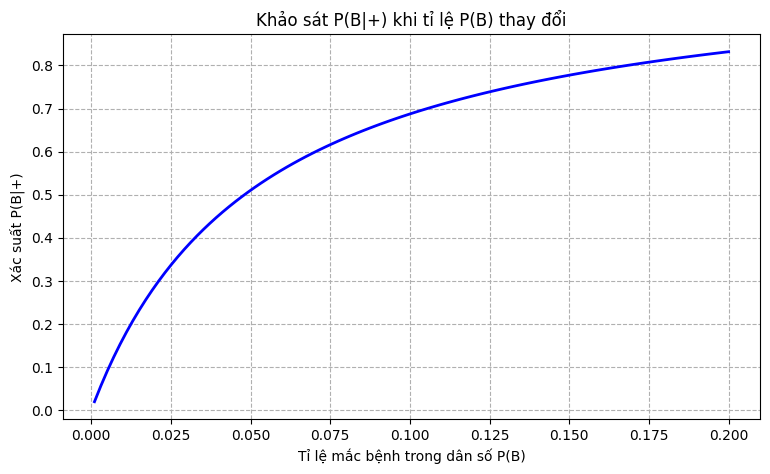

In [7]:
import numpy as np
import matplotlib.pyplot as plt
P_B = 0.01             
P_pos_given_B = 0.99   
P_pos_given_NB = 0.05  

P_pos = (P_pos_given_B * P_B) + (P_pos_given_NB * (1 - P_B))
P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"Xác suất hậu nghiệm P(B|+): {P_B_given_pos:.4f}")

P_B_array = np.linspace(0.001, 0.2, 100)
P_pos_array = (P_pos_given_B * P_B_array) + (P_pos_given_NB * (1 - P_B_array))
P_B_given_pos_array = (P_pos_given_B * P_B_array) / P_pos_array

plt.figure(figsize=(9, 5))
plt.plot(P_B_array, P_B_given_pos_array, color='blue', lw=2)
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất P(B|+)')
plt.title('Khảo sát P(B|+) khi tỉ lệ P(B) thay đổi')
plt.grid(True, linestyle='--')
plt.show()

Phần 4

Kết quả: Xác suất thực sự mắc bệnh khi có kết quả dương tính $P(B|+)$ chỉ xấp xỉ 16.5%.

Giải thích tính "phản trực giác": Dù độ nhạy của xét nghiệm rất cao ($99\%$), nhưng do căn bệnh này quá hiếm ($P(B) = 0.01$), số người khỏe mạnh trong dân số là cực kỳ lớn. Do đó, tỉ lệ dương tính giả tuy nhỏ ($5\%$) nhưng khi áp lên số lượng lớn người khỏe mạnh sẽ tạo ra một lượng "dương tính giả" hoàn toàn áp đảo số ca "dương tính thật" (Nghịch lý tỉ lệ cơ sở).